In [1]:
from google.colab import files

uploaded = files.upload()

Saving ab_data.csv to ab_data.csv


In [2]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv('/content/ab_data.csv')

# 데이터 크기
print('행 수:', len(df))
print('열 수:', len(df.columns))

# 열 이름
print('\n열 이름:')
print(df.columns.tolist())

# 앞부분 5행 확인
print('\n데이터 예시:')
display(df.head())

# 결측값 확인
print('\n결측값:')
print(df.isnull().sum())

# 중복 사용자 확인
print('\n중복 user_id 수:')
print(df['user_id'].duplicated().sum())

# 실험 그룹별 사용자 수
print('\n그룹별 행 수:')
print(df['group'].value_counts())

# 페이지별 행 수
print('\n페이지별 행 수:')
print(df['landing_page'].value_counts())

행 수: 294478
열 수: 5

열 이름:
['user_id', 'timestamp', 'group', 'landing_page', 'converted']

데이터 예시:


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1



결측값:
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

중복 user_id 수:
3894

그룹별 행 수:
group
treatment    147276
control      147202
Name: count, dtype: int64

페이지별 행 수:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64


In [3]:
# 그룹과 실제 노출 페이지의 조합 확인
print('그룹·페이지 조합:')
print(
    pd.crosstab(
        df['group'],
        df['landing_page']
    )
)

# 잘못 연결된 행 찾기
wrong_match = (
    ((df['group'] == 'control')
     & (df['landing_page'] == 'new_page'))
    |
    ((df['group'] == 'treatment')
     & (df['landing_page'] == 'old_page'))
)

print('\n잘못 연결된 행 수:')
print(wrong_match.sum())

# 잘못 연결된 데이터 제거
df_clean = df[~wrong_match].copy()

# 같은 사용자가 여러 번 나온 경우 한 번만 남기기
df_clean = df_clean.drop_duplicates(
    subset='user_id',
    keep='first'
)

# 정제 결과 확인
print('\n정제 전 행 수:', len(df))
print('정제 후 행 수:', len(df_clean))

print('\n정제 후 중복 user_id 수:')
print(df_clean['user_id'].duplicated().sum())

print('\n정제 후 그룹·페이지 조합:')
print(
    pd.crosstab(
        df_clean['group'],
        df_clean['landing_page']
    )
)

그룹·페이지 조합:
landing_page  new_page  old_page
group                           
control           1928    145274
treatment       145311      1965

잘못 연결된 행 수:
3893

정제 전 행 수: 294478
정제 후 행 수: 290584

정제 후 중복 user_id 수:
0

정제 후 그룹·페이지 조합:
landing_page  new_page  old_page
group                           
control              0    145274
treatment       145310         0


In [4]:
# 그룹별 전환 결과 계산
conversion_summary = (
    df_clean
    .groupby('group')['converted']
    .agg(
        users='count',
        conversions='sum',
        conversion_rate='mean'
    )
    .reset_index()
)

# 전환율을 퍼센트로 변경
conversion_summary['conversion_rate_pct'] = (
    conversion_summary['conversion_rate'] * 100
)

display(conversion_summary)

# 기존 페이지와 새 페이지의 전환율
control_rate = df_clean.loc[
    df_clean['group'] == 'control',
    'converted'
].mean()

treatment_rate = df_clean.loc[
    df_clean['group'] == 'treatment',
    'converted'
].mean()

# 두 그룹의 전환율 차이
difference = (
    treatment_rate - control_rate
) * 100

print(f'기존 페이지 전환율: {control_rate * 100:.2f}%')
print(f'새 페이지 전환율: {treatment_rate * 100:.2f}%')
print(f'전환율 차이: {difference:.2f}%p')

,group,users,conversions,conversion_rate,conversion_rate_pct
0,control,145274,17489,0.120386,12.038630
1,treatment,145310,17264,0.118808,11.880807


기존 페이지 전환율: 12.04%
새 페이지 전환율: 11.88%
전환율 차이: -0.16%p


In [5]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# 기존 페이지 데이터
control = df_clean[
    df_clean['group'] == 'control'
]['converted']

# 새 페이지 데이터
treatment = df_clean[
    df_clean['group'] == 'treatment'
]['converted']

# 각 그룹의 전환 수
conversion_counts = np.array([
    treatment.sum(),
    control.sum()
])

# 각 그룹의 전체 사용자 수
user_counts = np.array([
    len(treatment),
    len(control)
])

# 2표본 비율 Z검정
# 첫 번째 값인 treatment가 control보다 큰지 검정
z_stat, p_value = proportions_ztest(
    conversion_counts,
    user_counts,
    alternative='larger'
)

print(f'Z통계량: {z_stat:.4f}')
print(f'p-value: {p_value:.4f}')

# 유의수준
alpha = 0.05

if p_value < alpha:
    print('결론: 새 페이지의 전환율이 통계적으로 더 높습니다.')
else:
    print('결론: 새 페이지의 전환율이 더 높다는 증거가 없습니다.')

Z통계량: -1.3109
p-value: 0.9051
결론: 새 페이지의 전환율이 더 높다는 증거가 없습니다.


In [6]:
# 그룹별 전환율과 사용자 수
control_rate = control.mean()
treatment_rate = treatment.mean()

control_n = len(control)
treatment_n = len(treatment)

# 새 페이지 - 기존 페이지 전환율 차이
rate_difference = (
    treatment_rate - control_rate
)

# 전환율 차이의 표준오차
standard_error = np.sqrt(
    treatment_rate * (1 - treatment_rate) / treatment_n
    +
    control_rate * (1 - control_rate) / control_n
)

# 95% 신뢰구간
lower_bound = (
    rate_difference - 1.96 * standard_error
)

upper_bound = (
    rate_difference + 1.96 * standard_error
)

print(
    f'전환율 차이: '
    f'{rate_difference * 100:.3f}%p'
)

print(
    f'95% 신뢰구간: '
    f'{lower_bound * 100:.3f}%p '
    f'~ {upper_bound * 100:.3f}%p'
)

# 신뢰구간 해석
if lower_bound > 0:
    print('결론: 새 페이지가 전환율을 높였다고 볼 수 있습니다.')
elif upper_bound < 0:
    print('결론: 새 페이지가 전환율을 낮췄다고 볼 수 있습니다.')
else:
    print('결론: 신뢰구간에 0이 포함되어 유의한 차이를 확인할 수 없습니다.')

전환율 차이: -0.158%p
95% 신뢰구간: -0.394%p ~ 0.078%p
결론: 신뢰구간에 0이 포함되어 유의한 차이를 확인할 수 없습니다.


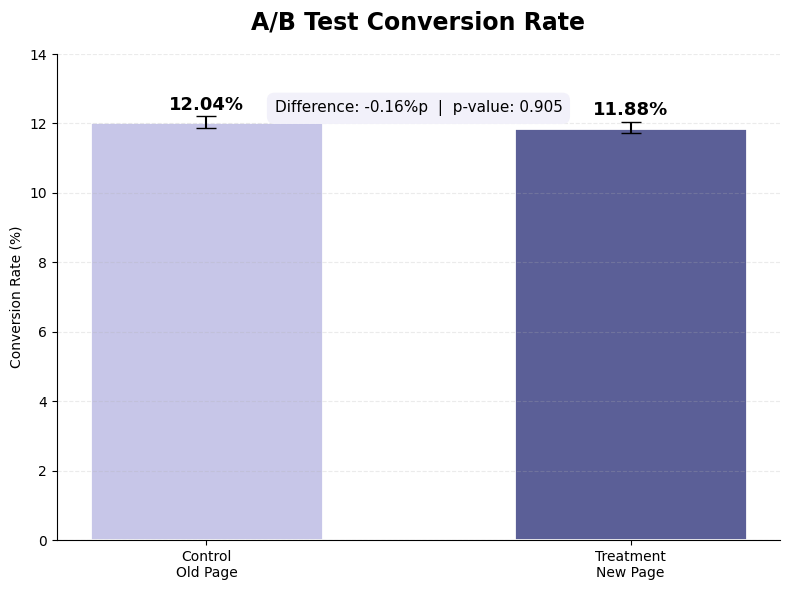

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from google.colab import files

plt.close('all')

# 1. 그룹별 데이터
control = df_clean[
    df_clean['group'] == 'control'
]['converted']

treatment = df_clean[
    df_clean['group'] == 'treatment'
]['converted']

# 2. 전환율
control_rate = control.mean()
treatment_rate = treatment.mean()

rates = np.array([
    control_rate,
    treatment_rate
]) * 100

# 3. 각 전환율의 95% 신뢰구간 오차
errors = np.array([
    1.96 * np.sqrt(
        control_rate * (1 - control_rate) / len(control)
    ),
    1.96 * np.sqrt(
        treatment_rate * (1 - treatment_rate) / len(treatment)
    )
]) * 100

# 4. Z검정
conversion_counts = np.array([
    treatment.sum(),
    control.sum()
])

user_counts = np.array([
    len(treatment),
    len(control)
])

z_stat, p_value = proportions_ztest(
    conversion_counts,
    user_counts,
    alternative='larger'
)

difference = (
    treatment_rate - control_rate
) * 100

# 5. 그래프 만들기
labels = [
    'Control\nOld Page',
    'Treatment\nNew Page'
]

colors = [
    '#C7C6E8',
    '#5B5F97'
]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    rates,
    yerr=errors,
    capsize=7,
    color=colors,
    width=0.55,
    edgecolor='white',
    linewidth=2
)

# 막대 위에 전환율 표시
for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f'{rate:.2f}%',
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

plt.title(
    'A/B Test Conversion Rate',
    fontsize=17,
    fontweight='bold',
    pad=18
)

plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 14)
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.gca().spines[['top', 'right']].set_visible(False)

# 검정 결과 표시
plt.text(
    0.5,
    0.88,
    f'Difference: {difference:.2f}%p  |  p-value: {p_value:.3f}',
    transform=plt.gca().transAxes,
    ha='center',
    fontsize=11,
    bbox={
        'boxstyle': 'round,pad=0.5',
        'facecolor': '#F2F1FA',
        'edgecolor': 'none'
    }
)

plt.tight_layout()

# 6. 이미지 저장
plt.savefig(
    '/content/07_ab_conversion_rate.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [8]:
files.download('/content/07_ab_conversion_rate.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from google.colab import files

# 1. 시간 형식 변경
df_clean['timestamp'] = pd.to_datetime(
    df_clean['timestamp']
)

# 2. 실험 기간
start_date = df_clean['timestamp'].min()
end_date = df_clean['timestamp'].max()
experiment_days = (end_date - start_date).days + 1

# 3. 그룹 데이터
control = df_clean[
    df_clean['group'] == 'control'
]['converted']

treatment = df_clean[
    df_clean['group'] == 'treatment'
]['converted']

# 4. 전환율
control_rate = control.mean()
treatment_rate = treatment.mean()
difference = treatment_rate - control_rate

# 5. Z검정
conversion_counts = np.array([
    treatment.sum(),
    control.sum()
])

user_counts = np.array([
    len(treatment),
    len(control)
])

z_stat, p_value = proportions_ztest(
    conversion_counts,
    user_counts,
    alternative='larger'
)

# 6. 전환율 차이의 95% 신뢰구간
standard_error = np.sqrt(
    treatment_rate * (1 - treatment_rate) / len(treatment)
    +
    control_rate * (1 - control_rate) / len(control)
)

lower_bound = difference - 1.96 * standard_error
upper_bound = difference + 1.96 * standard_error

# 7. 최종 의사결정
decision = (
    'Keep old page'
    if p_value >= 0.05
    else 'Launch new page'
)

# 8. 최종 결과표
ab_summary = pd.DataFrame([{
    'experiment_start': start_date.date(),
    'experiment_end': end_date.date(),
    'experiment_days': experiment_days,
    'control_users': len(control),
    'treatment_users': len(treatment),
    'control_conversions': int(control.sum()),
    'treatment_conversions': int(treatment.sum()),
    'control_rate_pct': round(control_rate * 100, 3),
    'treatment_rate_pct': round(treatment_rate * 100, 3),
    'difference_pp': round(difference * 100, 3),
    'ci_lower_pp': round(lower_bound * 100, 3),
    'ci_upper_pp': round(upper_bound * 100, 3),
    'z_statistic': round(z_stat, 4),
    'p_value': round(p_value, 4),
    'decision': decision
}])

display(ab_summary)

# 9. CSV로 저장
ab_summary.to_csv(
    '/content/20_ab_test_summary.csv',
    index=False
)

,experiment_start,experiment_end,experiment_days,control_users,treatment_users,control_conversions,treatment_conversions,control_rate_pct,treatment_rate_pct,difference_pp,ci_lower_pp,ci_upper_pp,z_statistic,p_value,decision
0,2017-01-02,2017-01-24,22,145274,145310,17489,17264,12.039,11.881,-0.158,-0.394,0.078,-1.3109,0.9051,Keep old page


In [10]:
files.download('/content/20_ab_test_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>